# ML Lab 02 – Phân loại đậu khô (Dry Bean)
**Đề bài:** phân loại `Class` với **≥ 7 feature** bằng KNN, AdaBoost/Cascade, Naive Bayes, Decision Tree.
Chia 80/20 hoặc 70/30. Output: **F1-Score, Confusion Matrix, AUC** cho tất cả mô hình.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42


def save_show(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, name), dpi=110, bbox_inches="tight")
    plt.show()

## 1. Khám phá dữ liệu

In [2]:
df = pd.read_excel(os.path.join(DATA_DIR, "Dry_Bean_Dataset.xlsx"))
print(f"Kích thước: {df.shape} · Giá trị thiếu: {df.isnull().sum().sum()} · Dòng trùng: {df.duplicated().sum()}")
df.describe().T.round(2)

Kích thước: (13611, 17) · Giá trị thiếu: 0 · Dòng trùng: 68


,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.28,29324.10,20420.00,36328.00,44652.00,61332.00,254616.00
Perimeter,13611.0,855.28,214.29,524.74,703.52,794.94,977.21,1985.37
MajorAxisLength,13611.0,320.14,85.69,183.60,253.30,296.88,376.50,738.86
MinorAxisLength,13611.0,202.27,44.97,122.51,175.85,192.43,217.03,460.20
AspectRation,13611.0,1.58,0.25,1.02,1.43,1.55,1.71,2.43
Eccentricity,13611.0,0.75,0.09,0.22,0.72,0.76,0.81,0.91
ConvexArea,13611.0,53768.20,29774.92,20684.00,36714.50,45178.00,62294.00,263261.00
EquivDiameter,13611.0,253.06,59.18,161.24,215.07,238.44,279.45,569.37
Extent,13611.0,0.75,0.05,0.56,0.72,0.76,0.79,0.87
Solidity,13611.0,0.99,0.00,0.92,0.99,0.99,0.99,0.99


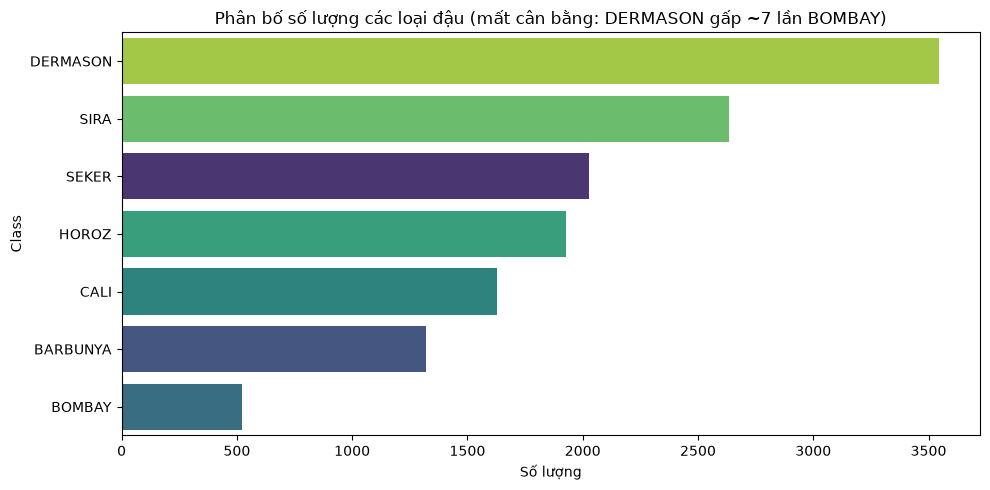

In [3]:
class_counts = df["Class"].value_counts()
plt.figure(figsize=(10, 5))
sns.countplot(y="Class", hue="Class", data=df, order=class_counts.index, palette="viridis", legend=False)
plt.title("Phân bố số lượng các loại đậu (mất cân bằng: DERMASON gấp ~7 lần BOMBAY)")
plt.xlabel("Số lượng"); plt.ylabel("Class")
save_show("class_distribution.png")

## 2. Chọn feature, chia train/test
- 8 feature hình học cơ bản (≥ 7 theo đề).
- Chia 80/20 **stratified** (giữ tỉ lệ các lớp) **trước**, chuẩn hóa **sau** (scaler nằm trong pipeline, chỉ fit trên train).

In [4]:
FEATURES = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength",
            "AspectRation", "Eccentricity", "ConvexArea", "EquivDiameter"]
X = df[FEATURES]
le = LabelEncoder()
y = le.fit_transform(df["Class"])
class_names = le.classes_
n_classes = len(class_names)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_train.shape} · Test: {X_test.shape}")

Train: (10888, 8) · Test: (2723, 8)


## 3. Huấn luyện & đánh giá 4 mô hình
- F1 **weighted** (lớp mất cân bằng) · AUC **One-vs-Rest** (7 lớp).

In [5]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5, weights="distance"),
    "Naive Bayes": GaussianNB(var_smoothing=1e-8),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2), n_estimators=100,
                                   learning_rate=0.5, random_state=RANDOM_STATE),
}

results = {}
for name, clf in models.items():
    model = make_pipeline(StandardScaler(), clf).fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    results[name] = {
        "F1-Score (Weighted)": f1_score(y_test, y_pred, average="weighted"),
        "AUC (OvR)": roc_auc_score(y_test, y_proba, multi_class="ovr"),
        "cm": confusion_matrix(y_test, y_pred),
        "proba": y_proba,
    }

performance = (pd.DataFrame({n: {k: v for k, v in r.items() if k not in ("cm", "proba")} for n, r in results.items()})
               .T.sort_values("F1-Score (Weighted)", ascending=False))
performance.round(4)

,F1-Score (Weighted),AUC (OvR)
KNN,0.9030,0.9755
Decision Tree,0.8810,0.9807
AdaBoost,0.8802,0.9701
Naive Bayes,0.8737,0.9870


## 4. Confusion Matrix

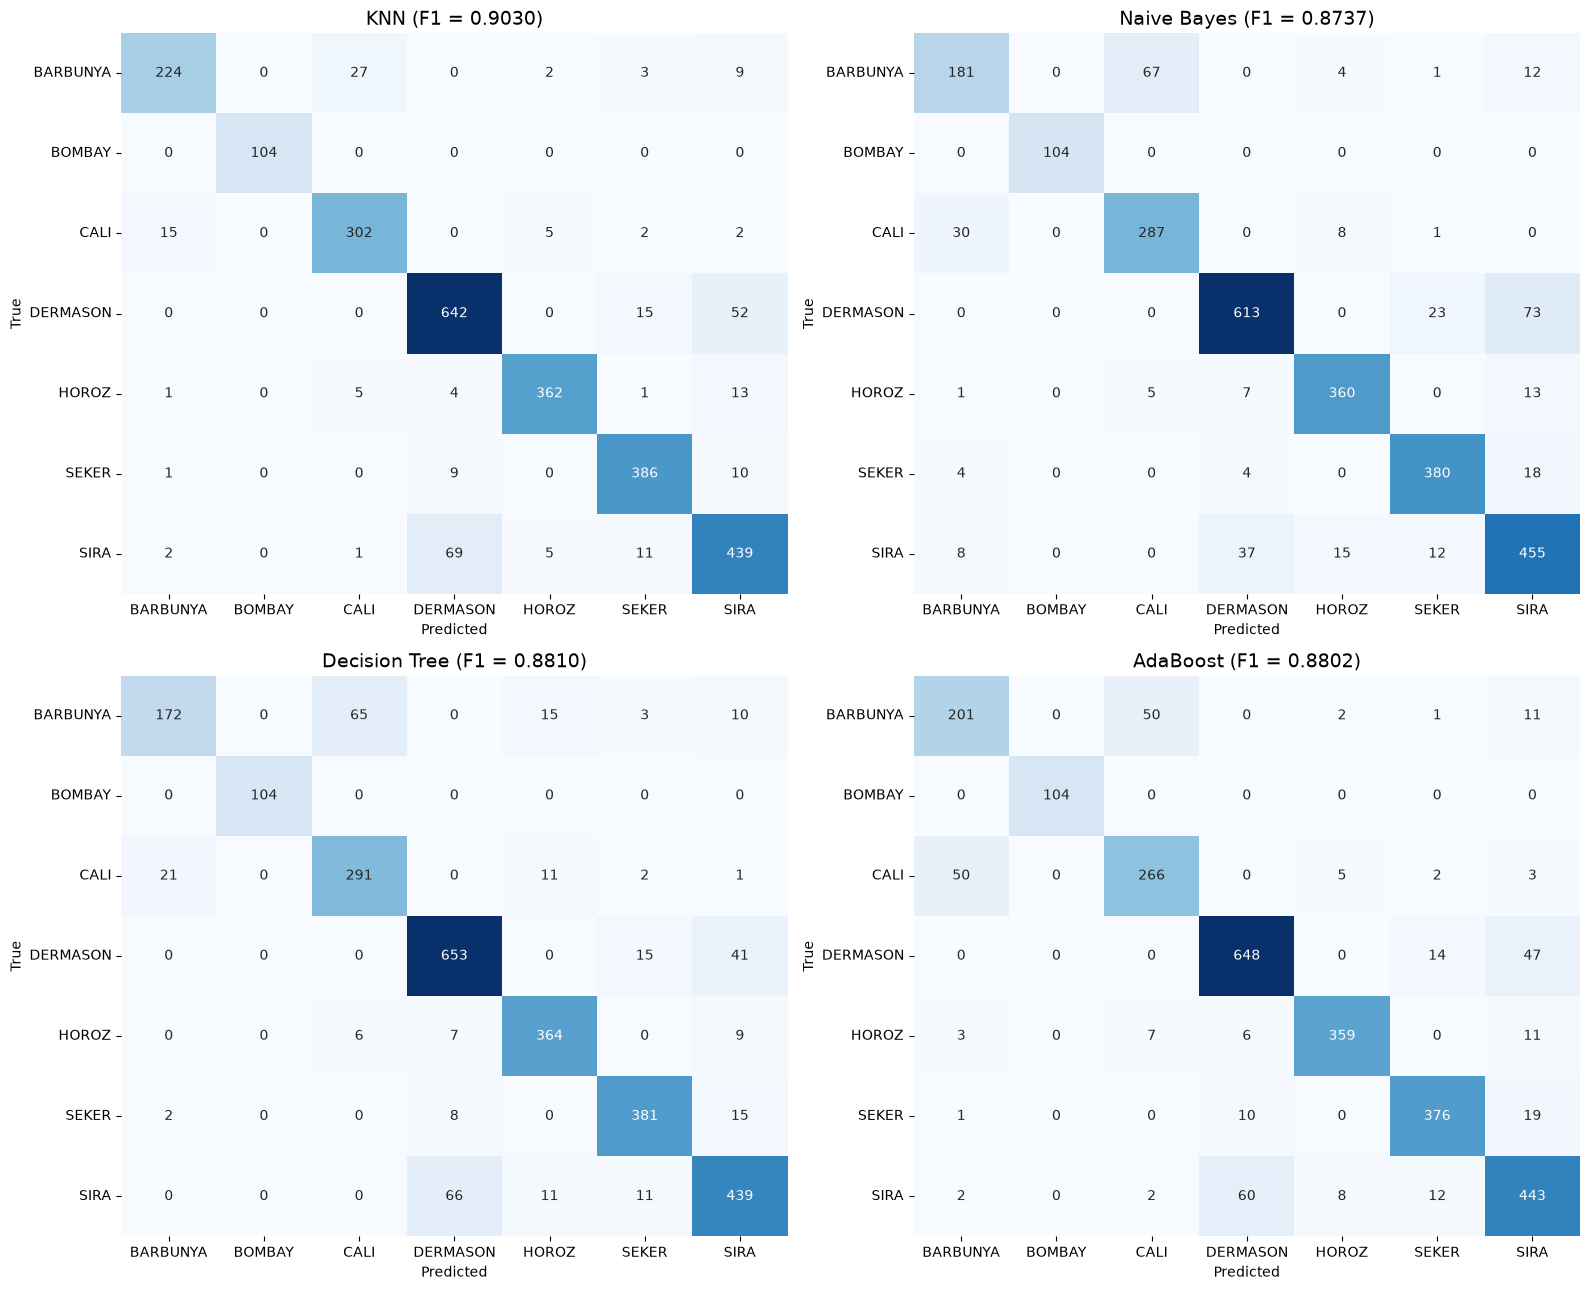

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
for ax, (name, r) in zip(axes.ravel(), results.items()):
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{name} (F1 = {r['F1-Score (Weighted)']:.4f})", fontsize=14)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
save_show("confusion_matrices.png")

## 5. ROC (macro-average, One-vs-Rest)
Nội suy TPR của 7 đường ROC lên cùng lưới FPR rồi lấy trung bình đều.

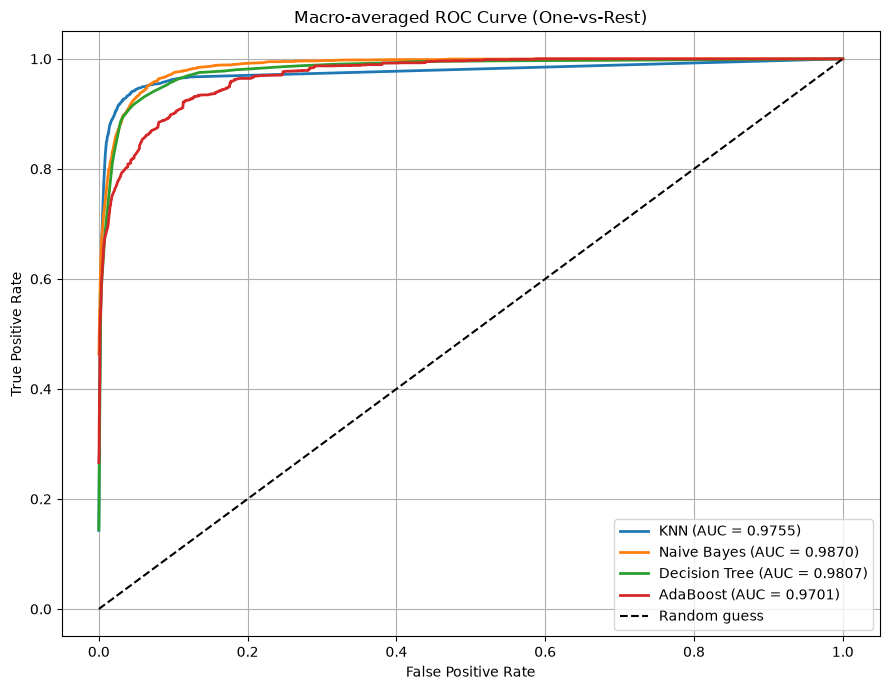

In [7]:
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
plt.figure(figsize=(9, 7))
for name, r in results.items():
    curves = [roc_curve(y_test_bin[:, i], r["proba"][:, i])[:2] for i in range(n_classes)]
    all_fpr = np.unique(np.concatenate([fpr for fpr, _ in curves]))
    mean_tpr = np.mean([np.interp(all_fpr, fpr, tpr) for fpr, tpr in curves], axis=0)
    plt.plot(all_fpr, mean_tpr, lw=2, label=f"{name} (AUC = {r['AUC (OvR)']:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Macro-averaged ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right"); plt.grid(True)
save_show("all_models_roc_curve.png")

In [8]:
with open(os.path.join(OUTPUT_DIR, "models_performance_report.md"), "w", encoding="utf-8") as f:
    f.write("# Kết quả phân loại Dry Bean\n\n" + performance.to_markdown(floatfmt=".4f") + "\n\n")
    for name, r in results.items():
        cm = pd.DataFrame(r["cm"], index=class_names, columns=class_names).to_string()
        f.write(f"## {name}\n\n```\n{cm}\n```\n\n")
print("Đã lưu outputs/models_performance_report.md")

Đã lưu outputs/models_performance_report.md


**Nhận xét:**
- **KNN** có F1 cao nhất; **Naive Bayes** có AUC cao nhất nhưng F1 thấp nhất – xếp hạng xác suất tốt, nhưng giả định "feature độc lập" bị vi phạm (Area, ConvexArea, EquivDiameter… gần như tỉ lệ thuận) nên nhãn cuối cùng hay sai.
- Mọi mô hình nhầm nhiều nhất ở cặp **DERMASON ↔ SIRA**; **BOMBAY** luôn đúng 100 % vì kích thước lớn vượt trội.